# Comparing Career Trajectories of Male and Female Soccer Players in FIFA

### Project members

Izzie Lee, 

Lola Xu, 2743123

Kris Son, 2700284

## Introduction

In this project, we examine the research question:  
Do male and female soccer players peak at the same age, and does their development gap move in a similar trajectory?

Under this research question, we have two subquestions we are research on: do male and female players reach their peak at the same age; does the development gap shrink at a similar rate for both genders?

In this project, we have three core variables:

- Age
- Overall rating : numerical summary of player's total ability & performance
- Development gap : potential rating - current overall rating

Age is one of the most important factors in understanding athelete's career.


Our analysis suggests that male and female players reach their peak on similar timelines. The development gap moves at nearly the same rate for both groups. Based on these datsets, the differences in rating levels were not clearly visible. We could guess that the difference in rating levels are influenced by outside factors like training opportunities (that are not included in this project). 

## Data Used: FIFA Players 2016 – 2022

### Women's player datasets
- `female_players_16.csv`
- `female_players_17.csv`
- `female_players_18.csv`
- `female_players_19.csv`
- `female_players_20.csv`
- `female_players_21.csv`
- `female_players_22.csv`

These files contain female player data from FIFA 16 through FIFA 22. Each dataset includes player information such as age, overall rating, and potential rating. 
### Men's player datasets
- `players_16.csv`
- `players_17.csv`
- `players_18.csv`
- `players_19.csv`
- `players_20.csv`
- `players_21.csv`
- `players_22.csv`

These files contain male player data from FIFA 16 through FIFA 22. Each dataset includes player information such as age, overall rating, and potential rating. 

## Data Description

For this study, we use 14 FIFA player dataset tables: seven female-player tables (`female_players_16.csv`, `female_players_17.csv`, `female_players_18.csv`, `female_players_19.csv`, `female_players_20.csv`, `female_players_21.csv`, and `female_players_22.csv`) and seven male-player tables (`players_16.csv`, `players_17.csv`, `players_18.csv`, `players_19.csv`, `players_20.csv`, `players_21.csv`, and `players_22.csv`). Each row in every table represents **one player in one FIFA edition**. Therefore, same player may appear in multiple years as separate observations. The female tables contain **248, 299, 317, 299, 345, 345, and 391 observations**, respectively, while the male tables contain **15,623, 17,596, 17,954, 18,085, 18,483, 18,944, and 19,239 observations**. These datasets include player-level information such as **age, overall rating, potential rating, nationality, club, position, and many other performance-related attributes**.

In [ ]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the data & labeling all dataset
female_player16= pd.read_csv("data/female_players_16.csv")
female_player17= pd.read_csv("data/female_players_17.csv")
female_player18= pd.read_csv("data/female_players_18.csv")
female_player19= pd.read_csv("data/female_players_19.csv")
female_player20= pd.read_csv("data/female_players_20.csv")
female_player21= pd.read_csv("data/female_players_21.csv")
female_player22= pd.read_csv("data/female_players_22.csv")

male_player16= pd.read_csv("data/players_16.csv")
male_player17= pd.read_csv("data/players_17.csv")
male_player18= pd.read_csv("data/players_18.csv")
male_player19= pd.read_csv("data/players_19.csv")
male_player20= pd.read_csv("data/players_20.csv")
male_player21= pd.read_csv("data/players_21.csv")
male_player22= pd.read_csv("data/players_22.csv")

/var/folders/v5/n9dnkhrn6q7bwvg6481lry2m0000gn/T/ipykernel_83798/1372230659.py:15: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  male_player16= pd.read_csv("data/players_16.csv")
/var/folders/v5/n9dnkhrn6q7bwvg6481lry2m0000gn/T/ipykernel_83798/1372230659.py:17: DtypeWarning: Columns (81,82,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  male_player18= pd.read_csv("data/players_18.csv")
/var/folders/v5/n9dnkhrn6q7bwvg6481lry2m0000gn/T/ipykernel_83798/1372230659.py:21: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  male_player22= pd.read_csv("data/players_22.csv")


In [28]:
# Stack all years into one DataFrame (Using for loops)
# lists to collect age, overall rating, and potential for ALL PLAYERS 
ages_f = []
overalls_f = []
potentials_f= []
for f in [female_player16, female_player17, female_player18, female_player19, female_player20, female_player21, female_player22]:
    ages_f += list(f["age"])
    overalls_f+= list(f["overall"])
    potentials_f += list(f["potential"])

ages_m = []
overalls_m = []
potentials_m = []
for m in [male_player16, male_player17, male_player18, male_player19, male_player20, male_player21, male_player22]:
    ages_m += list(m["age"])
    overalls_m+= list(m["overall"])
    potentials_m += list(m["potential"])

# Create a label (to keep track of gender)
gender_list=[]
for i in range(len(ages_f)) :
    gender_list.append("Female")
for i in range(len(ages_m)):
    gender_list.append("Male")

# Merge all into one DataFrame
# Includes: ge, overall rating, potential, gender 
df = pd.DataFrame({"age": ages_f + ages_m, "overall":overalls_f + overalls_m, "potential":potentials_f +potentials_m, "gender":gender_list})
df

,age,overall,potential,gender
0,32,91,91,Female
1,29,90,90,Female
2,35,90,90,Female
3,28,90,90,Female
4,27,89,89,Female
...,...,...,...,...
128163,22,47,52,Male
128164,19,47,59,Male
128165,21,47,55,Male
128166,19,47,60,Male


### Merging Procedures

 (refer to the codes above)
 
 In the beginning, we labeled each dataset with its corresponding year so that it would be easier to merge the datasets together.  In these datasets, our goal was to combine the 7 datasets (2016-2022) for female players together and the 7 datasets (2016-2022) for male players together. We used a list to stack players’ age, overall rating, and potential.  Because there were 7 datasets, we used a for loop. As one of the last steps, we created an empty list to put in the entries so that we could separate age, overall, and potential into female and male. The final step was to merge and create the data into one dataframe. 

In [36]:
# Split by gender
female_df = pd.DataFrame(df[df["gender"] == "Female"])
male_df = pd.DataFrame(df[df["gender"] == "Male"])

# Cleaning & Filtering 
female_counts = female_df.groupby("age")["overall"].count()
male_counts = male_df.groupby("age")["overall"].count()

# We are going to drop ages that have fewer than 5 players 
rare_female_ages= []
for age in female_counts.index:
    if female_counts[age]<5:
        rare_female_ages.append(age)

female_df["age"] = female_df["age"].replace(rare_female_ages, np.nan)

#  And, remove NaN values & create a clean version of female dataframe
clean_ages_f = []
clean_overall_f = []
clean_potential_f = []
for i in range(len(female_df)):
    if female_df["age"].values[i] == female_df["age"].values[i]:
        clean_ages_f.append(female_df["age"].values[i])
        clean_overall_f.append(female_df["overall"].values[i])
        clean_potential_f.append(female_df["potential"].values[i])
female_df = pd.DataFrame({"age": clean_ages_f, "overall": clean_overall_f, "potential": clean_potential_f})

# (Same process for male) Identify rare age (within male players)
rare_male_ages = []
for age in male_counts.index:
    if male_counts[age]<5:
        rare_male_ages.append(age)

male_df["age"] = male_df["age"].replace(rare_male_ages,np.nan)

# make a clean version of male Dataframe
clean_ages_m = []
clean_overall_m = []
clean_potential_m = []
for i in range(len(male_df)):
    if male_df["age"].values[i] == male_df["age"].values[i]:
        clean_ages_m.append(male_df["age"].values[i])
        clean_overall_m.append(male_df["overall"].values[i])
        clean_potential_m.append(male_df["potential"].values[i])
male_df = pd.DataFrame({"age": clean_ages_m, "overall": clean_overall_m, "potential": clean_potential_m})

### Main Columns: Age, Overall, and Potential

(refer to male_df & female_df, written below)

The key columns in our study are **age, overall, potential** and below are the codes that show the age, overall, potential of male players and the female players. The ultimate goal of our research is to figure out whether female players and male players reach their peak at the same age. Other than age, the reason why we chose overall rating and potential is that those two variables are the elements that best define the players' skill and their attractiveness as players. 

In [34]:
male_df

,age,overall,potential
0,28.0,94,95
1,30.0,93,93
2,31.0,90,90
3,29.0,90,90
4,28.0,90,90
...,...,...,...
125912,22.0,47,52
125913,19.0,47,59
125914,21.0,47,55
125915,19.0,47,60


In [35]:
female_df

,age,overall,potential
0,32.0,91,91
1,29.0,90,90
2,35.0,90,90
3,28.0,90,90
4,27.0,89,89
...,...,...,...
2235,18.0,66,81
2236,23.0,66,75
2237,19.0,66,79
2238,19.0,62,77


### Data Cleaning and Filtering

(refer to the codes above)


After merging the data, we split the dataframe by gender. The main purpose of the study is to compare the performances of females and males. Therefore, we separated the two datasets back into female and male players to filter the data more clearly. For each dataset, there were over 20,000 rows of data. Therefore, we considered the age to be an outlier (rare age) if there were fewer than five players in the dataset. We labeled those players as NaN (not a number) to prevent those numbers from ruining the results. These steps were repeated for both male datasets and female datasets. After finishing these steps (and taking out the NaNs), we considered our dataset to be clean.

,dataset,female_peak_age,female_mean_overall,male_peak_age,male_mean_overall
0,FIFA 16-22,36.0,80.2,33.0,69.5


,Age,Female Gap,Male Gap
0,17,18.8,17.3
1,22,8.2,8.0
2,25,3.8,3.4
3,30,0.0,0.0


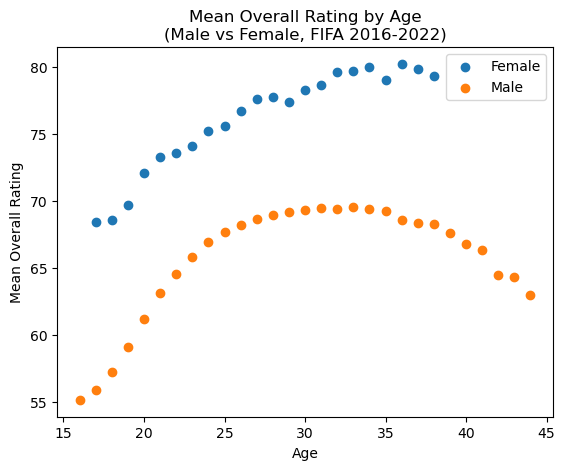

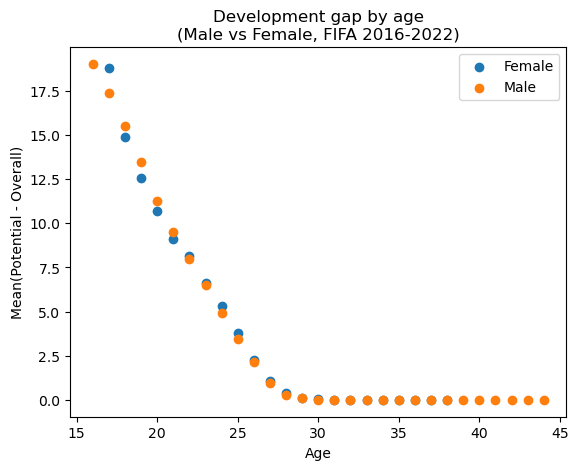

In [30]:

# Find "overall" mean by age (Grouping & Aggregating)
female_overall = female_df.groupby("age")["overall"].mean()
male_overall = male_df.groupby("age")["overall"].mean()


# Find development gap (potential - overall) 
female_df["gap"] = female_df["potential"] - female_df["overall"]
male_df["gap"] = male_df["potential"] - male_df["overall"]

female_gap =female_df.groupby("age")["gap"].mean()
male_gap = male_df.groupby("age")["gap"].mean()

# Summary Table (Merging using pd.merge)

# Find peak age for each gender
female_peak_age = female_overall.index[0]
for age in female_overall.index:
    if female_overall[age]>female_overall[female_peak_age]:
        female_peak_age = age

male_peak_age = male_overall.index[0]
for age in male_overall.index:
    if male_overall[age]>male_overall[male_peak_age]:
        male_peak_age=age

# Table 1: Peak Age Summary
female_summary = pd.DataFrame({"dataset": ["FIFA 16-22"], "female_peak_age": [female_peak_age], "female_mean_overall": [round(female_overall[female_peak_age], 1)]})
male_summary = pd.DataFrame({"dataset": ["FIFA 16-22"], "male_peak_age": [male_peak_age], "male_mean_overall": [round(male_overall[male_peak_age], 1)]})
peak_summary = pd.merge(left = female_summary, right = male_summary, how = "left", on = "dataset")
display(peak_summary)

# Table 2: Development Gap Summary by age
summary_data= {"Age":[], "Female Gap": [], "Male Gap": []}
for a in [17, 22, 25, 30]:
    female_g = female_df[female_df["age"]== a]["gap"].mean()
    male_g = male_df[male_df["age"]== a]["gap"].mean()
    summary_data["Age"].append(a)
    summary_data["Female Gap"].append(round(female_g, 1))
    summary_data["Male Gap"].append(round(male_g, 1))

summary_table = pd.DataFrame(summary_data)
display(summary_table)

# Visualization 

# Plots

# plot 1: Mean overall rating by age
plt.scatter(x = female_overall.index, y = female_overall.values,label = "Female")
plt.scatter(x = male_overall.index, y = male_overall.values,label = "Male")
plt.xlabel("Age")
plt.ylabel("Mean Overall Rating")
plt.title("Mean Overall Rating by Age\n(Male vs Female, FIFA 2016-2022)")
plt.legend()
plt.show()

#Plot 2: Development gap by age
plt.scatter(x= female_gap.index, y= female_gap.values, label = "Female")
plt.scatter(x= male_gap.index, y= male_gap.values, label = "Male")
plt.xlabel("Age")
plt.ylabel("Mean(Potential - Overall)")
plt.title("Development gap by age\n(Male vs Female, FIFA 2016-2022)")
plt.legend()
plt.show()

## Results

The two plots above show that male and female FIFA players follow very similar **development patter** though, their **average rating levels** are different. 
In the first plot, both groups move in a clear inverted-U shape. Mean overall ratings increase from the teenage years into early adulthood, and they reach their highest point during the late twenties. 

Female players remain above male players across all observed ages, but this should not be interested as one gender being better than the other. Usually, in the athletic field, the female dataset represents a narrower, more elite player pool, while the male data includes a much wider range of skill levels. Because of this, the rating level comparision is not perfectly equal to compare the two groups. 

The second plot is especially important because it shows the change in development gap of the two groups as the players age. The development gap decreases almost identically for both male and female players: it starts high in the teenage years, falls quickly through the early twenties, and reaches nearly zero by about age 28. As the player reaches the age near 30, both curves flatten. This indicates that players are generally treated as having reached their full development.

# Discussion

This study suggests that both male and female players associated in FIFA follows a similar trajectory, peaking in their late twenties. Based on our observation, we realized there is a big relationship between players' peak years and their tactical experience. And the variables that we chose, Age vs. Developmental gap, well-explained how players, regardless of their gender, seem to reach full potential after piling up their tactics. 

The major limitation for our study is that the two research elements are incomparable as one is too broad while the other is too restricted. There are thousands of male players from multiple tiers of professional soccer division leagues; on the other hand, For women's soccer, the game usually includes only the top-tier leagues and the major national teams. Therefore, the comparison is not ideal in this case, as the players are not put in a equal scale. 